# Fair Neural Sheaf Diffusion

## A topological perspective on fairness

This notebook is a proof of concept for our work in the intersecion of fairness and graph learning. The idea is to create spectral filters based on sensitive attributes in order to achieve fairness while leveraging the expressive power of sheaf models.

The main result guiding our intuition says as follows: let $G$ be a graph, $\mathcal{F}(t)$ a time-dependent sheaf on $G$, $L_t$ the time-dependent sheaf laplacian, and $s$ a vector defining a fairness metric through its dot product; that is, our fairness metric $F_t$ can be written as $F_t = s^T x_t$. For example, using $s = \mathbf{1}(A=1) - \mathbf{1}(A=0)$ results in $F = IND$.

Given a initial signal $x_0 \in \mathcal{C}^0(G; \mathcal{F})$ satisfying the sheaf diffusion equation:
$$
\frac{d x_t}{dt} = -L(t) x_t
$$
If the following inequality, the master condition from here on out, holds for some $\gamma > 0$ and all $t$: 
$$
s^T L_t x_t \geq \gamma s^T x_t
$$
Then the fairness metric tends to zero:
$$
F_t \longrightarrow 0
$$
We propose two alternative methods modify the time-dependent sheaf laplacian. $L_t \rightarrow \tilde{L_t}$ such that $s^T L_t x_t \gtrsim \gamma s^T x_t$ with the intention of creating a fair model according to $s$.

Before estarting we make the necessary imports:

In [1]:
import random
import sys
from pathlib import Path
path = Path("results/filter/figs")

# Machine learning and data science
import numpy as np
import pandas as pd
import networkx as nx
from sklearn.decomposition import PCA
from scipy.linalg import eigh
from scipy.sparse.linalg import eigsh, eigs
from scipy.sparse import coo_matrix
from gower import gower_matrix

# Plotting
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from matplotlib.collections import LineCollection
from matplotlib.ticker import AutoMinorLocator, MaxNLocator

from joypy import joyplot

# Pytorch
import torch
import torch.optim as optim
from torch_geometric.utils import remove_self_loops, to_undirected
from torch_sparse import spmm

sys.path.append('..')
# Custom imports
from utils.data_processing import data_loader, remove_duplicate_edges
from utils.constants import graph_datasets, tabular_datasets
from utils.training import SheafTrainer
from models.fair_filter import (
    PolyFilterDiscreteDiagSheafDiffusion,
    PolyFilterDiscreteBundleSheafDiffusion,
    PolyFilterDiscreteGeneralSheafDiffusion,
    SpectrumFilterDiscreteDiagSheafDiffusion,
    SpectrumFilterDiscreteBundleSheafDiffusion,
    SpectrumFilterDiscreteGeneralSheafDiffusion,
    VectorFilterDiscreteDiagSheafDiffusion,
    VectorFilterDiscreteBundleSheafDiffusion,
    VectorFilterDiscreteGeneralSheafDiffusion
)

/home/arturo_perez/.local/lib/python3.10/site-packages/torch/utils/cpp_extension.py:28: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import packaging  # type: ignore[attr-defined]


In [2]:
def diffusion(indices, values, x, size, n, vector=None, alpha=1.):
    x_tilde = x.clone()
    
    if vector is not None:
        if vector.dim() == 1:
            vector = vector.unsqueeze(1)

    for _ in range(n):
        propagation = spmm(indices, values, size, size, x_tilde)
        
        if vector is not None:
            projection_scalar = (x_tilde * vector).sum(dim=0, keepdim=True)
            contribution = alpha * projection_scalar * vector
            propagation = propagation + contribution
            
        x_tilde = x_tilde - propagation
        
    return x_tilde

def get_scipy_sparse(tensor):
    t = tensor.coalesce()
    indices = t.indices().cpu().numpy()
    values = t.values().cpu().numpy()
    return coo_matrix((values, (indices[0], indices[1])), shape=t.shape)

def compute_energy(L, x_signal, num_nodes, vector=None, alpha=1.):
    with torch.no_grad():
        if vector is not None:
            if vector.dim() == 1:
                vector = vector.unsqueeze(1)

        energy = x_signal * torch.sparse.mm(L, x_signal)
        
        if vector is not None:
            projection_scalar = (x_signal * vector).sum(dim=0, keepdim=True)
            contribution = alpha * projection_scalar * x_signal * vector
            energy = energy + contribution
            
        energy = energy.view(num_nodes, -1).sum(dim=1)

    return energy.cpu().numpy()

def get_node_styles(energy, sensitive):
    norm = plt.Normalize(energy.min(), energy.max())
    e_norm = norm(energy)
    sizes = 20 + 350 * e_norm
    node_colors = np.zeros((len(energy), 4))
    
    mask_unpriv = sensitive < 0
    mask_priv = sensitive >= 0
    
    cmap_u = plt.cm.Blues
    cmap_p = plt.cm.Reds
    intensities = 0.3 + 0.7 * e_norm
    
    node_colors[mask_unpriv] = cmap_u(intensities[mask_unpriv])
    node_colors[mask_priv] = cmap_p(intensities[mask_priv])
    
    return node_colors, sizes

def obtain_eig(laplacian, n_eig, which="SM", sparse=True):
    if sparse:
        vals, vecs = eigsh(laplacian, k=n_eig, which=which)
    else:
        vals, vecs = eigh(laplacian)

    vals, vecs = np.real(vals), np.real(vecs)
    sorted_ix = np.argsort(vals)
    vals = vals[sorted_ix]
    vecs = vecs[:, sorted_ix]

    if not sparse and which == 'SM':
        vals = vals[:n_eig]
        vecs = vecs[:, 0:n_eig]
    elif not sparse and which == 'LM':
        vals = vals[-n_eig:]
        vecs = vecs[:, -n_eig:]
    return vals, vecs

def get_transport_trajectory(P, nodes, d, vector=None, alpha=1.):
    P = P.to_dense()
    
    vec = torch.ones(d, 1).to(P.device)
    vec = vec / torch.norm(vec)
    
    traj = [torch.norm(vec).item()]
    
    if vector is not None and vector.dim() == 1:
        vector = vector.unsqueeze(1)
    
    for i in range(len(nodes)-1):
        u, v = nodes[i], nodes[i+1]
        rho_uv = P[u*d : (u+1)*d, v*d : (v+1)*d]
        
        vec = torch.matmul(rho_uv, vec)
        
        if vector is not None:
            proj = (vec * vector).sum() * vector
            vec = vec + alpha * proj
            
        traj.append(torch.norm(vec).item())
        
    return traj

def compute_cycle_holonomies_with_groups(P, list_of_cycles, sensitive, vector=None, alpha=1., d=3):
    P_dense = P.to_dense()
    s_np = sensitive.cpu().numpy().flatten()
    data = []

    if vector is not None:
        if vector.dim() == 1:
            vector = vector.unsqueeze(1)
        proj_mat = torch.matmul(vector, vector.t())
    
    for cycle in list_of_cycles:
        nodes = cycle + [cycle[0]]
        vec = torch.ones(d, 1, device=P.device)
        vec = vec / torch.norm(vec)
        
        for i in range(len(nodes)-1):
            u, v = nodes[i], nodes[i+1]
            rho_uv = P_dense[u*d : (u+1)*d, v*d : (v+1)*d]
            vec = torch.matmul(rho_uv, vec)
            
            if vector is not None:
                sub_proj_mat = proj_mat
                proj = torch.matmul(sub_proj_mat, vec)
                vec = vec + alpha * proj
                
        data.append({
            'Energy': torch.norm(vec).item(),
            'Group': f"S={int(s_np[cycle[0]] < 0)}"
        })
    return data

In [3]:
# Set a seed for reproductibility


seed = 42

def set_seed(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    return

set_seed(seed)

### Preliminary data processing

In [4]:
# Graph arguments
args = {
    'data': 'german',           
    'device': 'cuda' if torch.cuda.is_available() else 'cpu',
    'delta': 0.5,              
    'metric': 'euclidean',     
    'k': 10,                    
    'distance': False,           
    'knn': True,                
    'subset': False,             
    'star': False,              
    'folds': 5,                 
    'kfold': False,             
}

# Training parameters
lr = 3e-3
beta1 = 0.9
beta2 = 0.9999
decay = 1e-4
k_con = args['k']
epochs = 10
trace = False
metric = 'euclidean'

# Torch artifacts
optimizer = lambda x: optim.AdamW(x, lr=lr, betas=(beta1, beta2), weight_decay=decay)
criterion = torch.nn.BCEWithLogitsLoss()
device = torch.device(args['device'])

processor = data_loader(args['data'], device=device)

# Sensitive attribute
df = processor.df
sensitive_var = processor.sensitive
sensitive = df[[sensitive_var]]

privileged_indices = np.where(sensitive == 1)[0]
unprivileged_indices = np.where(sensitive == 0)[0]

# Graph creation
subset = {1000: privileged_indices, 1001: unprivileged_indices}
kwargs = {
    'subset': {1: privileged_indices, 2: unprivileged_indices},
    'aggregator_edges': [(1,2)],
    'radius': args['delta'],
    'metric': args['metric'],
    'k': args['k']
}

if not args['kfold']:
    data, edges = (processor
                   .create_graph(unit_ball=args['distance'], k_neigh=args['knn'], sub=args['subset'], star=args['star'], **kwargs)
                   .split(train_ratio=0.7, val_ratio=0.15, test_ratio=0.15)
                   .build())
else:
    data, edges = (processor
                   .create_graph(unit_ball=args['distance'], k_neigh=args['knn'], sub=args['subset'], star=args['star'], **kwargs)
                   .build())
    folds = processor.cross_validate(k_folds=args['folds'], stratify=data.y)


edges = {k: remove_duplicate_edges(edges[k]) for k in edges.keys()}

A = df.drop(columns=['Target']).columns.get_loc(sensitive_var)
sensitive_col = data.x[:, A]  # [num_nodes]

numeric_idx = [df.columns.get_loc(col) for col in processor.numeric]

# Send to device
data.x = data.x.to(device)
data.y = data.y.to(device)
sensitive_col = sensitive_col.to(device)
edge_index = data.edge_index.to(device)

if args['data'] in graph_datasets:
    edge_index = remove_duplicate_edges(edge_index)
    edge_index = to_undirected(edge_index)
elif args['data'] in tabular_datasets:
    edge_index, _ = remove_self_loops(edge_index)
    edge_index = to_undirected(edge_index)

REWEIGHTING = True

def choose_criterion(rw, data, train_mask, device):
    if not rw:
        criterion = torch.nn.BCEWithLogitsLoss()
    else:
        num_pos = data.y[train_mask].sum()
        num_neg = (data.y[train_mask] == 0).sum()
        weight_value = num_neg / (num_pos + 1e-6)
        pos_weight = torch.tensor([weight_value], device=device)
        criterion = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    return criterion

print(f"Number of rows: {df.shape[0]}")
print(f"Number of features: {df.shape[1]}")
print(f"Positive label proportion: {df['Target'].mean()}")
print(f"Sensitive group rate: {(1-sensitive_col).mean():.3f}")


Number of rows: 1000
Number of features: 63
Positive label proportion: 0.7
Sensitive group rate: 0.149


## Polynomial Spectral filter

If $L_t = V^T \Lambda V$ is such that all eigenvectors $v_{t,i}$ with eigenvalues $\lambda_{t,i}$ such that $s^T v_{t,i} > 0$ satisfy $\lambda_{t,i} \geq \lambda_0 > 0$. Let us call this set of eigenvalues the $s$ spectrum of $L_t$, $spec_s(L_t)$. It is easy to see that the spectrum of $L_t$ does not need to fulfill that inequality.

However, suppose we can create spectral filter $V^T \Phi(\Lambda) V$ such that $\Phi(\lambda) \approx \lambda$ for all $\lambda \notin spec_s(L_t)$ and $\Phi(\lambda) \gtrsim \lambda_0$ for all $\lambda \in spec_s(L_t)$ (kind of a dirac comb on the $s$ spectrum). In order to build such a function we define a sum of gaussian spikes with peaks on a set of target eigenvalues, $T$:

$$
\Phi(\lambda) = \lambda + \sum_{\lambda_0 \in T} \gamma_{\lambda_0} \exp\left(\left(\frac{\lambda - \lambda_0}{2\sigma_{\lambda_0}} \right)^2\right)  
$$

In order to obtain a stable approximation of this filter we use Tchebyshev polynomials, resulting in a poynomial $P \approx \Phi$. Furthermore, $P(L_t) = V^T P(\Lambda) V$ thus resulting in the desired filtering. The target set $T$ is estimated from the smallest eigenvalues of $L_t$ not counting the kernel, which is enough for our purposes.

We then do the substitution $L_t \rightarrow P(L_t)$, which satisfies the master condition and allows us to obtain a fair diffusion.

This procedure is implemented through the `PolyFilter` classes shown below. This method is implemented through **post-processing**, as the estimation of the polynomial filter is done once the sheaf laplacian has been learnt.

In [5]:
set_seed(seed)

k_eig=100
k_select=1
K_cheb=71
gamma=0.3
sigma=0.001
mode="topk"
weighted=True
nonzero=True
n_points = 10000000
epsilon = 0.01

k_selects = [0.01, 3]
modes = ["threshold", "topk"]

model_args = {
    'input_dim': df.shape[1]-1,
    'hidden_channels': 64,
    'output_dim': 1,
    'd': 2,
    'graph_size': df.shape[0] if not args['subset'] else df.shape[0] + 2,
    'layers': 5,
    'max_t': 1.0,
    'linear': True,
    'use_act': False,
    'sheaf_act': 'id',
    'orth': 'euler',
    'sparse_learner': True,
    'edge_weights': True,
    'normalised': True,
    'deg_normalised': False,
    'left_weights': False,
    'right_weights': False,
    'second_linear': False,
    'reg_strength': 0.5,
    'dropout': 0.5,
    'input_dropout': 0.1,
    'device': 'cuda' if torch.cuda.is_available() else 'cpu',
    'add_lp': False,
    'add_hp': False
}

dim = model_args['hidden_channels'] * (model_args['d'] + model_args['add_lp'] + model_args['add_hp'])
s = 1.0 * (sensitive_col == 1) - 1.0 * (sensitive_col == 0)

results = {}

if not args['kfold']:

    print(f'Training\n' + '-'*20)

    model = PolyFilterDiscreteGeneralSheafDiffusion(edge_index, model_args).to(device)

    criterion = choose_criterion(REWEIGHTING, data, data.train_mask, device)

    trainer = SheafTrainer(
        data,
        model,
        optimizer,
        criterion,
        sensitive_col,
        device = device,
        metric = metric,
        k = k_con,
        precomputed = False,
        distances = None
    )

    print('Results for validation set - UNFILTERED')
    val_results = trainer.train_model(
            eval = 'val',
            full_trace = trace,
            epochs = epochs,
            )

    print('Results for test set - UNFILTERED')
    test_results = trainer.evaluate()   
    print('='*20)

    results['unfiltered'] = {'val': val_results, 'test': test_results}

    s = s.repeat_interleave(model.final_d)
    model.set_filter(s, k_eig=k_eig, select=k_select, K_cheb=K_cheb, gamma=gamma, sigma=sigma, n_points=n_points, mode=mode, nonzero=nonzero, weighted=weighted, epsilon=epsilon)

    print('Results for validation set - FILTERED')
    val_results = trainer.evaluate(test=False)   
    print('Results for test set - FILTERED')
    test_results = trainer.evaluate()   
    print('='*20)

    results['unfiltered'] = {'val': val_results, 'test': test_results}

Training
--------------------
Results for validation set - UNFILTERED
Acc: 0.4800 | Bal. acc: 0.4640 | Idp: 0.0240 | Suf: 0.0430 | Sep: 0.1667 | Con: 0.4953 | Lip: 0.0180 | Ent: 0.4615
Results for test set - UNFILTERED
Acc: 0.7133 | Bal. acc: 0.7096 | Idp: 0.0967 | Suf: 0.0751 | Sep: 0.0267 | Con: 0.9967 | Lip: 0.0008 | Ent: 1.2442
Results for validation set - FILTERED
Acc: 0.6800 | Bal. acc: 0.6320 | Idp: 0.0240 | Suf: 0.0375 | Sep: 0.1367 | Con: 1.0000 | Lip: 0.0001 | Ent: 1.0625
Results for test set - FILTERED
Acc: 0.7467 | Bal. acc: 0.7299 | Idp: 0.0289 | Suf: 0.0394 | Sep: 0.0618 | Con: 0.9980 | Lip: 0.0001 | Ent: 1.4737


In [ ]:
size = model.hidden_dim*model.graph_size
L = torch.sparse_coo_tensor(
    model._laplacians[0][0].long().to(device),  model._laplacians[0][1].float().to(device)
    ).coalesce()
P = model.give_filter_matrix(layer=0, smdp=True)
P = P.coalesce()

laplacians_torch = {'Original': L, 'Polynomial': P}

L_sp = get_scipy_sparse(L)
P_sp = get_scipy_sparse(P)

laplacians_sp = {'Original': L_sp, 'Polynomial': P_sp}

s_tensor = s.clone()
s_tensor = s_tensor / torch.norm(s_tensor, p=2)

filter = model.filter

with torch.no_grad():
    bund_proj = model.lin1(data.x)

## Spectral Eigenvalue Filtering

The idea is similar to the previous method, although instead of filtering using a polynomial filter, we perform a more precise intervetion. Once again, we select the sensitive spectrum of $L_t$, but instead of performing a filter inside its spectrum, we modify the sensitive spectrum through its orthogonal projection. Formally:

$$
L_t \longrightarrow \tilde{L}_t = L_t + \sum_{\lambda \in spec_s(L_t)} f(\lambda) v_{\lambda} v_{\lambda}^T
$$

We can efficiently implement this with:

$$
\tilde{L}_t x_{t-1} = L_t x_{t-1} + \sum_{\lambda \in spec_s(L_t)} f(\lambda)\langle v_{\lambda},  x_{t-1}\rangle v_{\lambda} 
$$

This method is more stable but we suspect it might generalize worse due to how targeted it is.

In [ ]:
set_seed(seed)

k_eig=200
select=5
f=0.2
mode="topk"

k_selects = [0.01, 3]
modes = ["threshold", "topk"]

model_args.update({
    'reg_strength': 0.5,
}) 

dim = model_args['hidden_channels'] * (model_args['d'] + model_args['add_lp'] + model_args['add_hp'])
s = 1.0 * (sensitive_col == 1) - 1.0 * (sensitive_col == 0)

results = {}

if not args['kfold']:

    print(f'Training\n' + '-'*20)

    model = SpectrumFilterDiscreteGeneralSheafDiffusion(edge_index, model_args).to(device)

    criterion = choose_criterion(REWEIGHTING, data, data.train_mask, device)

    trainer = SheafTrainer(
        data,
        model,
        optimizer,
        criterion,
        sensitive_col,
        device = device,
        metric = metric,
        k = k_con,
        precomputed = False,
        distances = None
    )

    print('Results for validation set - UNFILTERED')
    val_results = trainer.train_model(
            eval = 'val',
            full_trace = trace,
            epochs = epochs,
            )

    print('Results for test set - UNFILTERED')
    test_results = trainer.evaluate()   
    print('='*20)

    results['unfiltered'] = {'val': val_results, 'test': test_results}

    s = s.repeat_interleave(model.final_d)
    model.set_filter(s, f=f, k_eig=k_eig, select=select, mode=mode)
    print('Results for validation set - FILTERED')
    val_results = trainer.evaluate(test=False)   
    print('Results for test set - FILTERED')
    test_results = trainer.evaluate()   
    print('='*20)

    results['unfiltered'] = {'val': val_results, 'test': test_results}

Training
--------------------
Results for validation set - UNFILTERED
Acc: 0.5133 | Bal. acc: 0.5160 | Idp: 0.1760 | Suf: 0.0021 | Sep: 0.1209 | Con: 0.5327 | Lip: 0.0192 | Ent: 0.5274
Results for test set - UNFILTERED
Acc: 0.7133 | Bal. acc: 0.7240 | Idp: 0.0262 | Suf: 0.1126 | Sep: 0.0201 | Con: 0.9927 | Lip: 0.0005 | Ent: 1.2442
Results for validation set - FILTERED
Acc: 0.6600 | Bal. acc: 0.6200 | Idp: 0.0480 | Suf: 0.0199 | Sep: 0.1291 | Con: 0.9960 | Lip: 0.0002 | Ent: 0.9706
Results for test set - FILTERED
Acc: 0.7467 | Bal. acc: 0.7299 | Idp: 0.0289 | Suf: 0.0394 | Sep: 0.0618 | Con: 0.9993 | Lip: 0.0001 | Ent: 1.4737


In [ ]:
values = model.filter[0]['values']
vectors = model.filter[0]['vectors']

## Vector filtering

The final idea is easier and basically ammounts to making the substituion:
$$
L_t \longrightarrow \tilde{L}_t = L_t + \alpha s s^T
$$
for a big enough value of $\alpha$ the master condition is fulfilled and thus the diffusion process results in a fair solution.

The diffusion process can be efficiently implemented as:
$$
\tilde{L}_t x_{t-1} = L_t x_{t-1} + \alpha \langle s,  x_{t-1}\rangle s 
$$
which avoids computing the \tilde{L}_t which may not be sparse.

This is implemented through the `VectorFilter` classes shown below. This method is implemented through **post-processing**, if the filtering is done after training the model, or as **in-processing**, if the filter is applied during training.

In [ ]:
set_seed(seed)

s = 1.0 * (sensitive_col == 1) - 1.0 * (sensitive_col == 0)

model_args.update({
    'vectors': s,
    'reg_strength': 1.5
})

optimizer = lambda x: optim.AdamW(x, lr=lr, betas=(beta1, beta2), weight_decay=decay)
criterion = torch.nn.BCEWithLogitsLoss()

results = {}

if not args['kfold']:

    print(f'Training\n' + '-'*20)

    model = VectorFilterDiscreteGeneralSheafDiffusion(edge_index, model_args).to(device)

    criterion = choose_criterion(REWEIGHTING, data, data.train_mask, device)

    trainer = SheafTrainer(
        data,
        model,
        optimizer,
        criterion,
        sensitive_col,
        device = device,
        metric = metric,
        k = k_con,
        precomputed = False,
        distances = None
    )

    print('Results for validation set - UNFILTERED')
    val_results = trainer.train_model(
            eval = 'val',
            full_trace = trace,
            epochs = epochs,
            )

    print('Results for test set - UNFILTERED')
    test_results = trainer.evaluate()   
    print('='*20)

    results['unfiltered'] = {'val': val_results, 'test': test_results}

    model.set_filter()
    print('Results for validation set - FILTERED - UNTRAINED')
    val_results = trainer.evaluate(test=False)   

    print('Results for test set - FILTERED - UNTRAINED')
    test_results = trainer.evaluate()   
    print('='*20)

    results['filtered_untrained'] = {'val': val_results, 'test': test_results}

    model = VectorFilterDiscreteDiagSheafDiffusion(edge_index, model_args).to(device)

    model.set_filter()
    trainer = SheafTrainer(
        data,
        model,
        optimizer,
        criterion,
        sensitive_col,
        device = device,
        metric = metric,
        k = k_con,
        precomputed = False,
        distances = None
    )

    print('Results for validation set - FILTERED - TRAINED')
    val_results = trainer.train_model(
            eval = 'val',
            full_trace = trace,
            epochs = epochs,
            )

    print('Results for test set - FILTERED - TRAINED')
    test_results = trainer.evaluate()   
    print('='*20)

    results['filtered_trained'] = {'val': val_results, 'test': test_results}

Training
--------------------
Results for validation set - UNFILTERED
Acc: 0.5133 | Bal. acc: 0.5160 | Idp: 0.1760 | Suf: 0.0021 | Sep: 0.1209 | Con: 0.5320 | Lip: 0.0192 | Ent: 0.5274
Results for test set - UNFILTERED
Acc: 0.7133 | Bal. acc: 0.7240 | Idp: 0.0262 | Suf: 0.1126 | Sep: 0.0201 | Con: 0.9933 | Lip: 0.0005 | Ent: 1.2442
Results for validation set - FILTERED - UNTRAINED
Acc: 0.6467 | Bal. acc: 0.6280 | Idp: 0.1440 | Suf: 0.0031 | Sep: 0.1225 | Con: 0.9920 | Lip: 0.0005 | Ent: 0.9151
Results for test set - FILTERED - UNTRAINED
Acc: 0.7133 | Bal. acc: 0.7240 | Idp: 0.0262 | Suf: 0.1126 | Sep: 0.0201 | Con: 0.9947 | Lip: 0.0005 | Ent: 1.2442
Results for validation set - FILTERED - TRAINED
Acc: 0.5000 | Bal. acc: 0.4600 | Idp: 0.1120 | Suf: 0.1416 | Sep: 0.2383 | Con: 0.5133 | Lip: 0.0212 | Ent: 0.5000
Results for test set - FILTERED - TRAINED
Acc: 0.4733 | Bal. acc: 0.5054 | Idp: 0.0370 | Suf: 0.0886 | Sep: 0.0701 | Con: 0.9980 | Lip: 0.0031 | Ent: 0.4494


## Visualizations

In [ ]:
reg_strength = model_args['reg_strength']
stalk_dim = L.size()[0] // sensitive_col.size()[0]
source = s_tensor.reshape(s_tensor.size()[0], 1)
bund_proj = bund_proj.view(1000, -1)

sensitive_col = 1.0* (sensitive_col == 1) - 1.0*(sensitive_col < 1)

### Filter

/tmp/ipykernel_3500667/2555477393.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


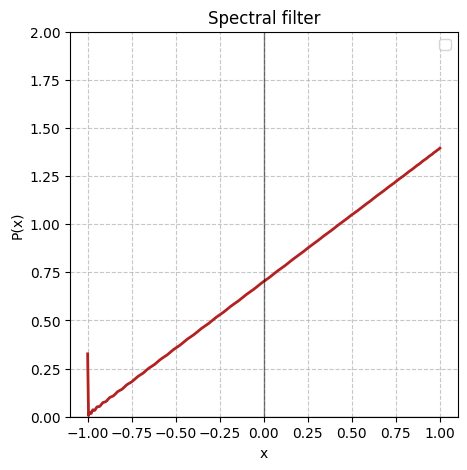

In [ ]:
coeffs = filter[0]['coeffs'].cpu().numpy()

poly = np.polynomial.Chebyshev(coeffs)
x = np.linspace(-1, 1, 400)
y = poly(x)

plt.figure(figsize=(5, 5))
plt.plot(x, y, color='firebrick', linewidth=2)
plt.axhline(0, color='black', lw=1, alpha=0.5)
plt.axvline(0, color='black', lw=1, alpha=0.5)

plt.title("Spectral filter")
plt.xlabel("x")
plt.ylabel("P(x)")
plt.ylim((0,2))
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

### Spectrum

In [ ]:
k = 21
which = 'SM'

colors = {'Original': 'blue', 'Polynomial': 'orange', 'Vector': 'green'}

In [ ]:
projector = np.outer(s_tensor.cpu().numpy(), s_tensor.cpu().numpy())

eigenproj = f * sum(torch.outer(vectors[:,i], vectors[:,i]) for i in range(vectors.shape[1]))
eigenproj = eigenproj.cpu().numpy()
eff_eigenproj = f * sum(vectors[:,i] for i in range(vectors.shape[1]))

V_sp = reg_strength * projector + L_sp
S_sp = eigenproj + L_sp
n_eigvals = 21
x = np.arange(n_eigvals)

vals_L, vecs_L = obtain_eig(L_sp, n_eigvals, which='SM', sparse=True)
vals_P, vecs_P = obtain_eig(P_sp, n_eigvals, which='SM', sparse=True)
vals_V, vecs_V = obtain_eig(V_sp, n_eigvals, which='SM', sparse=True)
vals_S, vecs_S = obtain_eig(S_sp, n_eigvals, which='SM', sparse=True)

correlations_L = s_tensor.cpu().numpy() @ vecs_L
correlations_P = s_tensor.cpu().numpy() @ vecs_P
correlations_V = s_tensor.cpu().numpy() @ vecs_V
correlations_S = s_tensor.cpu().numpy() @ vecs_S

width = 0.2
offset = 0.

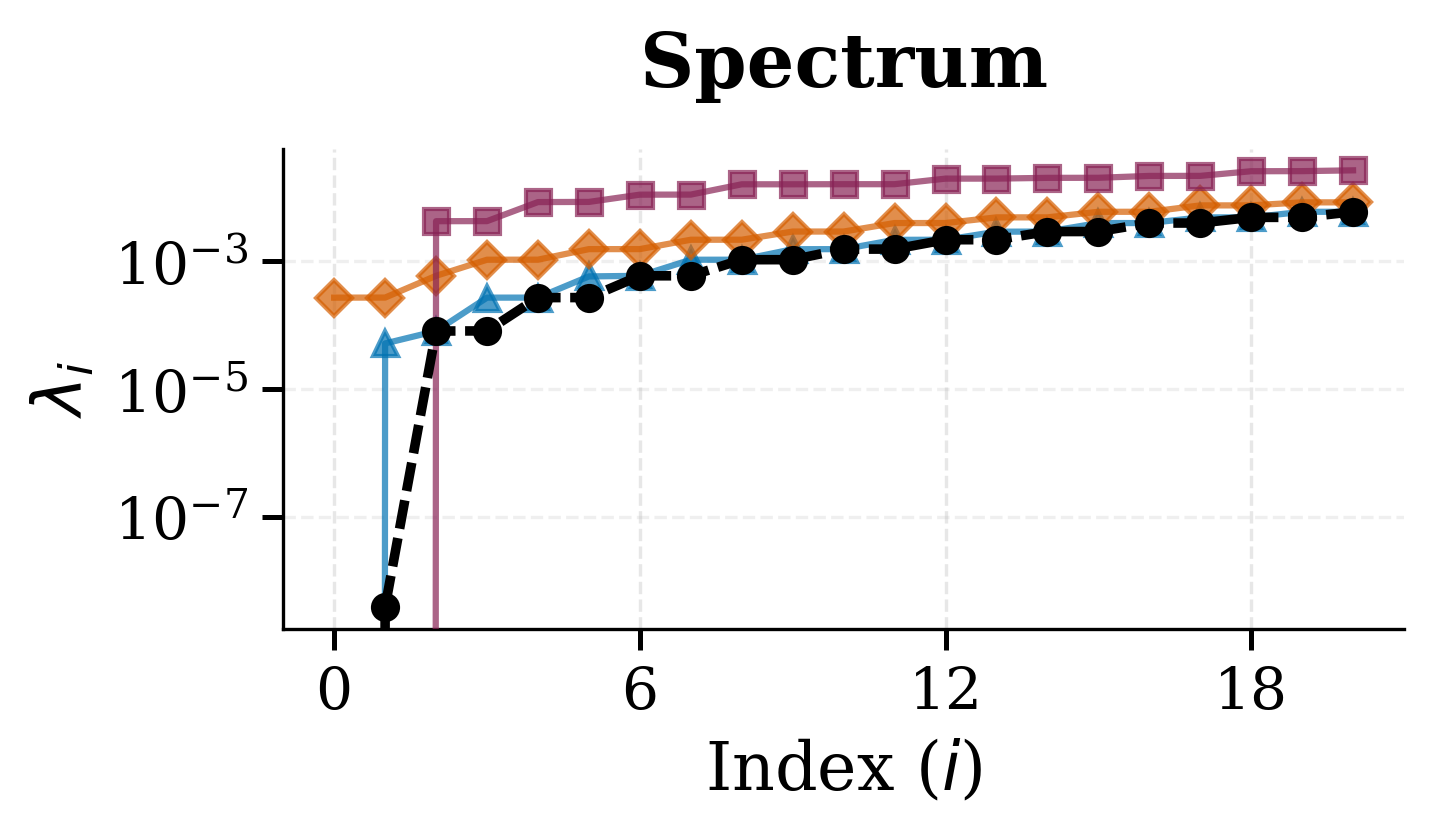

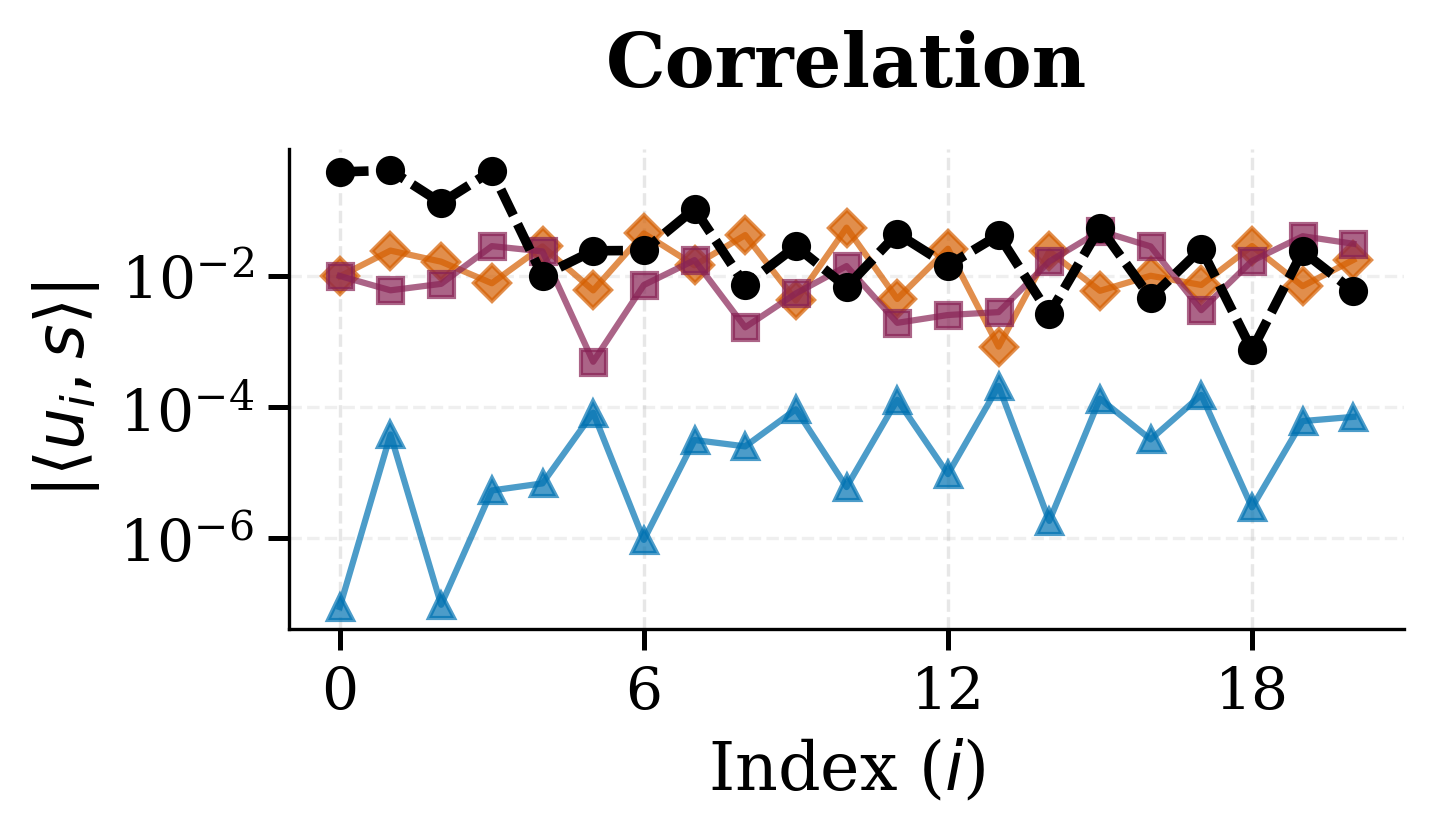

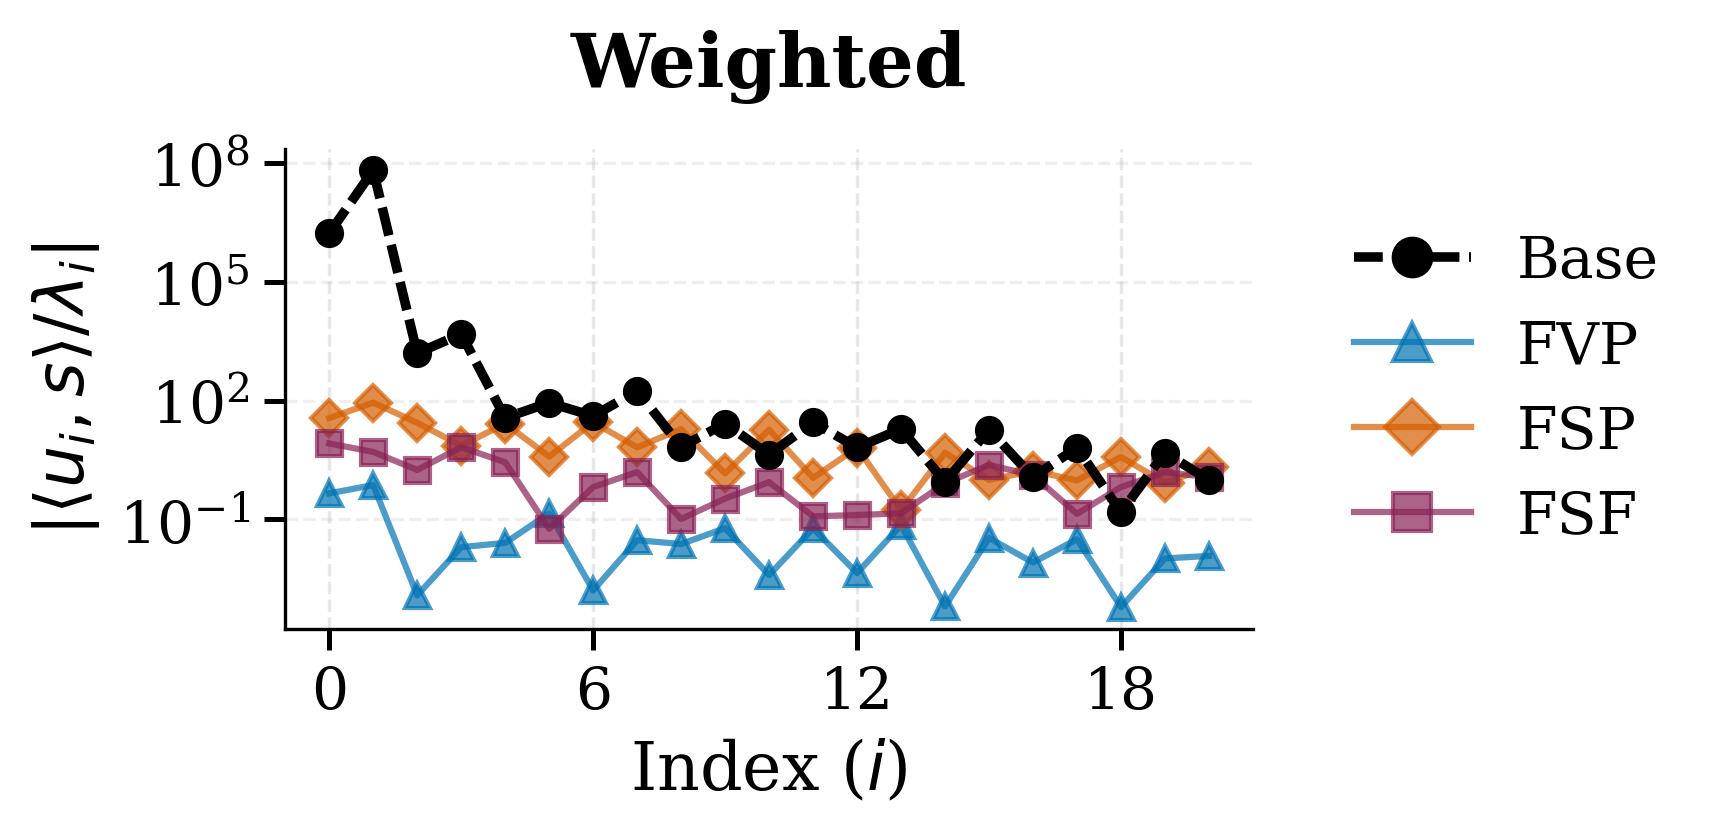

In [ ]:
plt.rcParams.update({
    "text.usetex": False, 
    "font.family": "serif",
    "font.size": 14,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "grid.linestyle": "--",
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "axes.labelsize": 16,
    "axes.titlesize": 18
})

colors = ['#000000', '#D55E00', '#0072B2', '#882255']
markers = ['o', 's', '^', 'D']

base_style = {
    'color': colors[0], 
    'marker': markers[0], 
    'dashes': (3, 1),
    'linewidth': 2.3, 
    'alpha': 1.0, 
    'zorder': 10
}

other_style = {
    'linewidth': 1.5, 
    'alpha': 0.7, 
    'zorder': 5
}

fig, ax = plt.subplots(figsize=(5, 3), dpi=300)

x_axis = np.arange(n_eigvals)

ax.plot(x_axis, vals_V+1e-8, label='FVP', color=colors[2], marker=markers[2], **other_style)
ax.plot(x_axis, vals_S+1e-8, label='FSP', color=colors[1], marker=markers[3], **other_style)
ax.plot(x_axis, vals_P+1e-8, label='FSF', color=colors[3], marker=markers[1], **other_style)
ax.plot(x_axis, vals_L+1e-8, label='Base', **base_style)

ax.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=4))

ax.tick_params(axis='both', which='major', direction='out', length=5, width=1.2)
ax.tick_params(axis='y', which='minor', direction='out', length=3)

ax.set_xlabel(r"Index ($i$)")
ax.set_ylabel(r"$\lambda_i$")
ax.set_title("Spectrum", fontweight='bold', pad=15)

ax.grid(True, which='both', axis='y', ls='--', alpha=0.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.yscale('log')
plt.tight_layout()
plt.savefig(path / "spectrum_compact.pdf", bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(5, 3), dpi=300)

ax.plot(x_axis, np.abs(correlations_V), label='FVP', color=colors[2], marker=markers[2], **other_style)
ax.plot(x_axis, np.abs(correlations_S), label='FSP', color=colors[1], marker=markers[3], **other_style)
ax.plot(x_axis, np.abs(correlations_P), label='FSF', color=colors[3], marker=markers[1], **other_style)
ax.plot(x_axis, np.abs(correlations_L), label='Base', **base_style)

ax.set_yscale("log")
ax.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=4))

ax.tick_params(axis='both', which='major', direction='out', length=5, width=1.2)
ax.tick_params(axis='y', which='minor', direction='out', length=3)

ax.set_xlabel(r"Index ($i$)")
ax.set_ylabel(r"$|\langle u_i , s \rangle|$")
ax.set_title("Correlation", fontweight='bold', pad=15)

ax.grid(True, which='both', axis='y', ls='--', alpha=0.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(path / "correlations_compact.pdf", bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(6, 3), dpi=300)

ax.plot(x_axis, np.abs(correlations_L/vals_L), label='Base', **base_style)
ax.plot(x_axis, np.abs(correlations_V/vals_V), label='FVP', color=colors[2], marker=markers[2], **other_style)
ax.plot(x_axis, np.abs(correlations_S/vals_S), label='FSP', color=colors[1], marker=markers[3], **other_style)
ax.plot(x_axis, np.abs(correlations_P/vals_P), label='FSF', color=colors[3], marker=markers[1], **other_style)

ax.set_yscale("log")
ax.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=4))

ax.tick_params(axis='both', which='major', direction='out', length=5, width=1.2)
ax.tick_params(axis='y', which='minor', direction='out', length=3)

ax.set_xlabel(r"Index ($i$)")
ax.set_ylabel(r"$|\langle u_i , s \rangle / \lambda_i|$")
ax.set_title("Weighted", fontweight='bold', pad=15)

ax.grid(True, which='both', axis='y', ls='--', alpha=0.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

legend = ax.legend(loc='center left', 
                   bbox_to_anchor=(1.05, 0.5),
                   ncol=1, 
                   frameon=False,
                   fontsize=14,
                   markerscale=1.5)

plt.tight_layout()
plt.savefig(path / "spectrum_correlations_compact.pdf", bbox_inches='tight')
plt.show()

### Diffusion of the sensitive vector

In [ ]:
figsize = (4, 4)
n = 1

<Figure size 500x400 with 0 Axes>

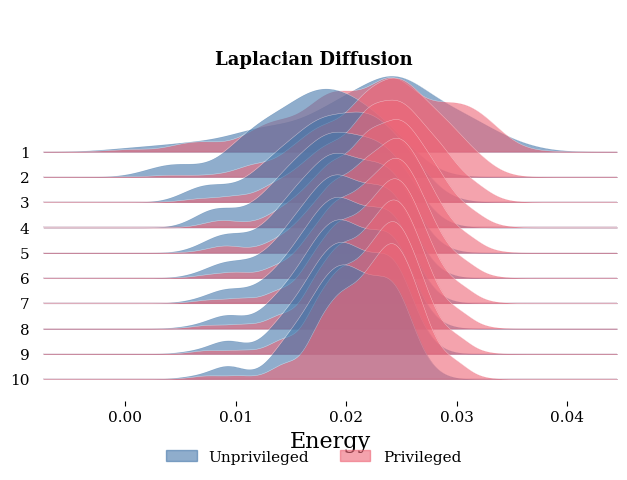

<Figure size 500x400 with 0 Axes>

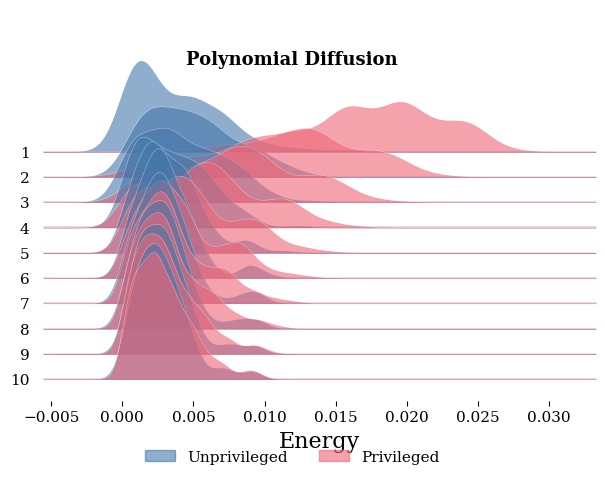

<Figure size 500x400 with 0 Axes>

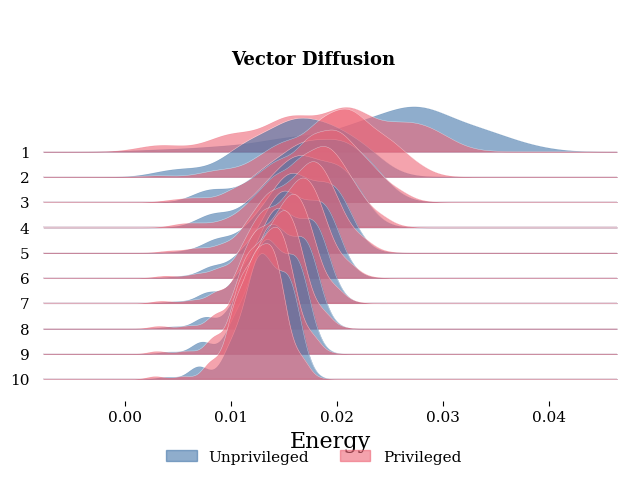

<Figure size 500x400 with 0 Axes>

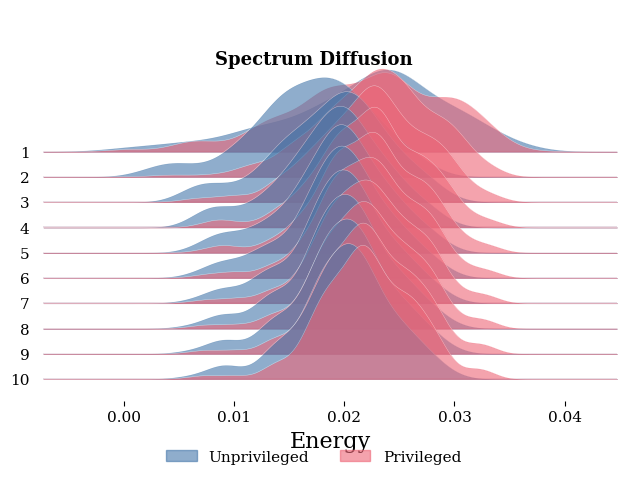

In [ ]:
plt.rcParams.update({
    "text.usetex": False, 
    "font.family": "serif",
    "font.size": 11,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "grid.linestyle": "--"
})

n_values = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
alpha_val = 0.1
stalk_dim_val = stalk_dim
s_np = sensitive_col.cpu().numpy().flatten()

indices_L = L.coalesce().indices()
values_L = L.coalesce().values()
indices_P = P.coalesce().indices()
values_P = P.coalesce().values()
size = L.size()[0]

col_unprivileged = '#4477AA'
col_privileged = '#EE6677'

data_dict = {'Laplacian': [], 'Polynomial': [], 'Vector': [], 'Spectrum': []}

for n in n_values:
    h_L = diffusion(indices_L, values_L, source.clone(), size, n)
    h_P = diffusion(indices_P, values_P, source.clone(), size, n)
    h_V = diffusion(indices_L, values_L, source.clone(), size, n, vector=source, alpha=alpha_val)
    h_S = diffusion(indices_L, values_L, source.clone(), size, n, vector=eff_eigenproj, alpha=1.0)
    
    current_signals = {'Laplacian': h_L, 'Polynomial': h_P, 'Vector': h_V, 'Spectrum': h_S}
    
    for method, h_tensor in current_signals.items():
        h_reshaped = h_tensor.detach().cpu().view(-1, stalk_dim_val)
        mags = torch.norm(h_reshaped, p=2, dim=1).numpy()
        
        df_temp = pd.DataFrame({'Energy': mags})
        df_temp['n'] = n
        df_temp['Unprivileged'] = np.where(s_np < 0, mags, np.nan)
        df_temp['Privileged'] = np.where(s_np >= 0, mags, np.nan)
        data_dict[method].append(df_temp)

for method in ['Laplacian', 'Polynomial', 'Vector', 'Spectrum']:
    df_method = pd.concat(data_dict[method], ignore_index=True)
    df_method['n'] = df_method['n']
    
    plt.figure(figsize=(5, 4))
    fig, axes = joyplot(
        data=df_method, 
        by='n', 
        column=['Unprivileged', 'Privileged'], 
        color=[col_unprivileged, col_privileged],
        alpha=0.6, 
        overlap=2.0,
        linewidth=0.3,
        linecolor='white',
        grid=False,
    )
    plt.suptitle(f"{method} Diffusion", y=0.88, fontsize=13, fontweight='bold')
    plt.xlabel("Energy")
    plt.ylabel("Layer")

    patch_unpriv = mpatches.Patch(color=col_unprivileged, label='Unprivileged', alpha=0.6)
    patch_priv = mpatches.Patch(color=col_privileged, label='Privileged', alpha=0.6)

    fig.legend(handles=[patch_unpriv, patch_priv], 
               loc='lower center', 
               ncol=2,
               bbox_to_anchor=(0.5, -0.01), 
               frameon=False)
    plt.subplots_adjust(bottom=0.15)
    plt.savefig(path / f"energy_{method}.jpg")
    plt.show()

<Figure size 350x250 with 0 Axes>

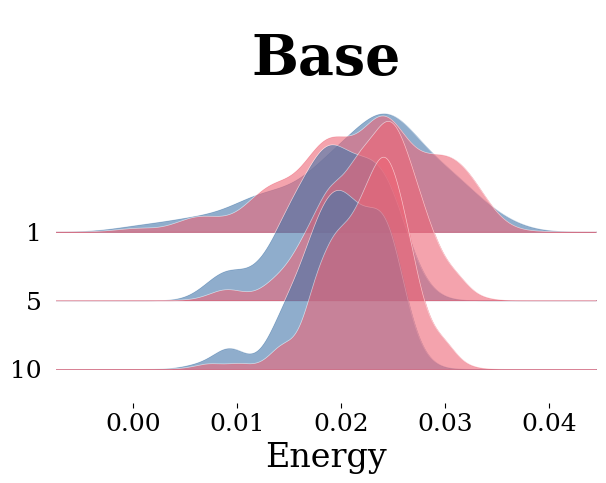

<Figure size 350x250 with 0 Axes>

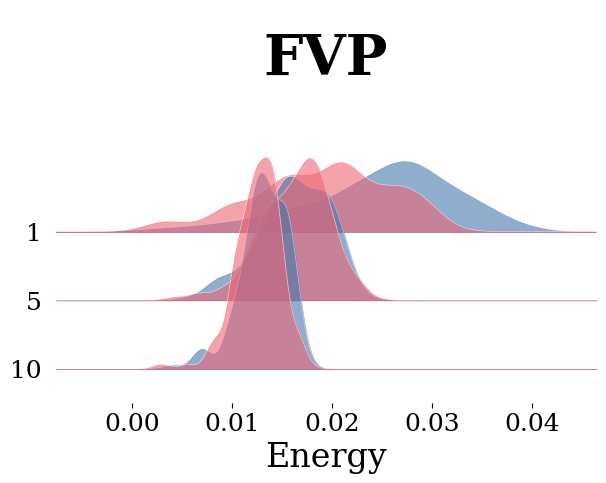

<Figure size 350x250 with 0 Axes>

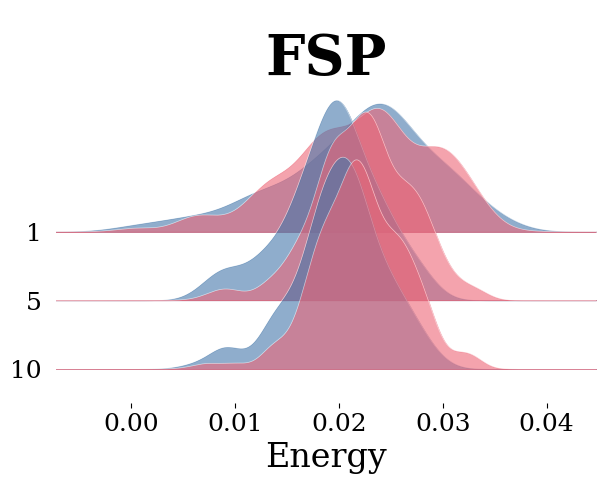

<Figure size 600x250 with 0 Axes>

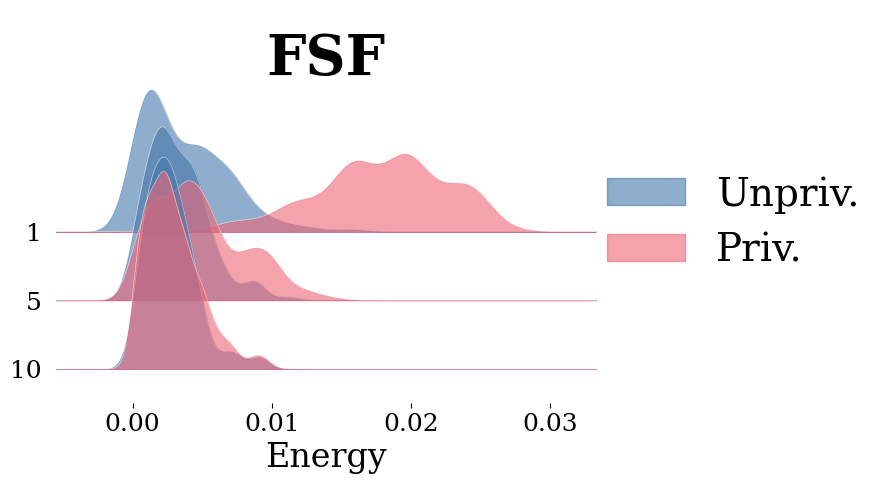

In [ ]:
plt.rcParams.update({
    "text.usetex": False, 
    "font.family": "serif",
    "font.size": 18,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "grid.linestyle": "--",
    "xtick.labelsize": 18,
    "ytick.labelsize": 18
})

n_values = [1, 5, 10]
alpha_val = 0.1
stalk_dim_val = stalk_dim
s_np = sensitive_col.cpu().numpy().flatten()

indices_L = L.coalesce().indices()
values_L = L.coalesce().values()
indices_P = P.coalesce().indices()
values_P = P.coalesce().values()
size = L.size()[0]

col_unprivileged = '#4477AA'
col_privileged = '#EE6677'

data_dict = {'Base': [], 'FSF': [], 'FVP': [], 'FSP': []}

for n in n_values:
    h_L = diffusion(indices_L, values_L, source.clone(), size, n)
    h_P = diffusion(indices_P, values_P, source.clone(), size, n)
    h_V = diffusion(indices_L, values_L, source.clone(), size, n, vector=source, alpha=alpha_val)
    h_S = diffusion(indices_L, values_L, source.clone(), size, n, vector=eff_eigenproj, alpha=1.0)
    
    current_signals = {'Base': h_L, 'FSF': h_P, 'FVP': h_V, 'FSP': h_S}
    
    for method, h_tensor in current_signals.items():
        h_reshaped = h_tensor.detach().cpu().view(-1, stalk_dim_val)
        mags = torch.norm(h_reshaped, p=2, dim=1).numpy()
        
        df_temp = pd.DataFrame({'Energy': mags})
        df_temp['n'] = n
        df_temp['Unprivileged'] = np.where(s_np < 0, mags, np.nan)
        df_temp['Privileged'] = np.where(s_np >= 0, mags, np.nan)
        data_dict[method].append(df_temp)

for method in ['Base', 'FVP', 'FSP', 'FSF']:
    df_method = pd.concat(data_dict[method], ignore_index=True)
    
    if method == 'FSF':
        plt.figure(figsize=(6.0, 2.5))
        plt.subplots_adjust(left=0.15, right=0.6, top=0.85, bottom=0.25)
    else:
        plt.figure(figsize=(3.5, 2.5))
        plt.subplots_adjust(left=0.15, right=0.95, top=0.85, bottom=0.25)

    fig, axes = joyplot(
        data=df_method, 
        by='n', 
        column=['Unprivileged', 'Privileged'], 
        color=[col_unprivileged, col_privileged],
        alpha=0.6, 
        overlap=1.5,
        linewidth=0.5,
        linecolor='white',
        grid=False,
    )
    
    for ax in axes:
        ax.tick_params(axis='both', which='major', labelsize=18)

    axes[0].text(0.5, 0.7, f"{method}", 
                 transform=axes[0].transAxes, 
                 ha='center', va='bottom', 
                 fontsize=40, fontweight='bold')

    axes[-1].set_xlabel("Energy", fontsize=24)

    patch_unpriv = mpatches.Patch(color=col_unprivileged, label='Unpriv.', alpha=0.6)
    patch_priv = mpatches.Patch(color=col_privileged, label='Priv.', alpha=0.6)

    if method == 'FSF': 
        fig.legend(handles=[patch_unpriv, patch_priv], 
                   loc='center left', 
                   ncol=1,
                   bbox_to_anchor=(0.92, 0.5), 
                   frameon=False,
                   fontsize=28)
    
    plt.savefig(path / f"ridge_{method}.pdf", bbox_inches='tight', dpi=150)
    plt.show()

### Graph by Dirichlet energy

In [ ]:
n = 2
figsize = (6, 6)
alpha = 0.03
k = 0.001
seed = seed

if n == 1:
    signal_L = source
    signal_P = source
    signal_V = source
    signal_S = source
else:
    signal_L = diffusion(indices_L, values_L, source.clone(), size, n)
    signal_P = diffusion(indices_P, values_P, source.clone(), size, n)
    signal_V = diffusion(indices_L, values_L, source.clone(), size, n, vector=source, alpha=alpha_val)
    signal_S = diffusion(indices_L, values_L, source.clone(), size, n, vector=eff_eigenproj, alpha=1.0)


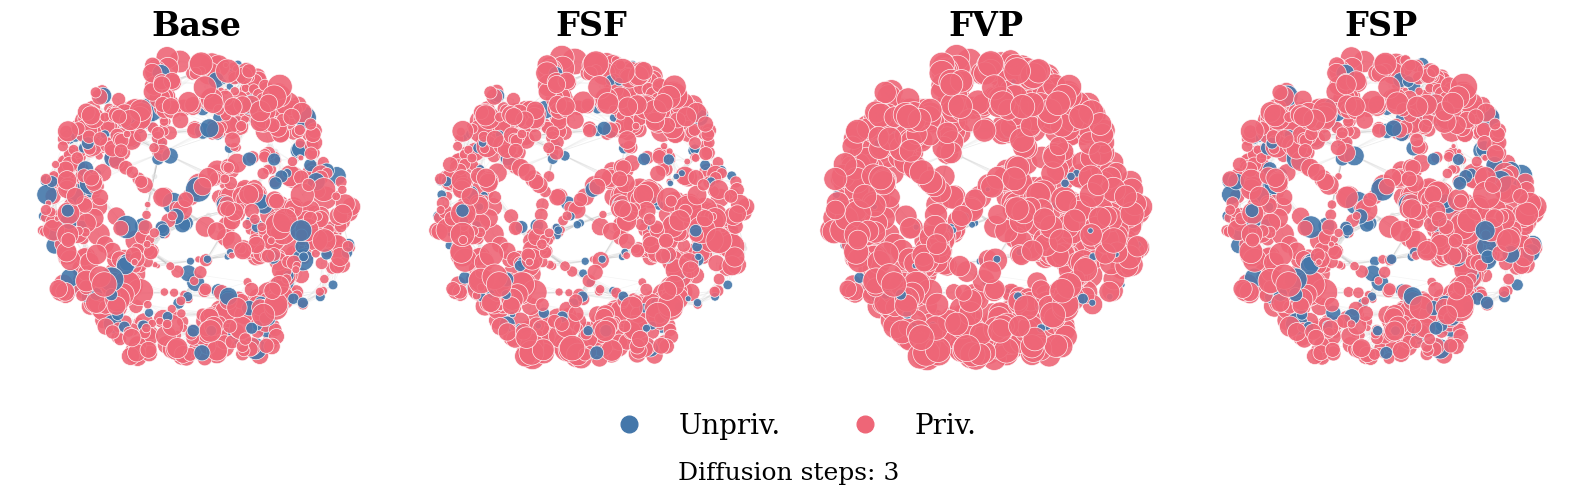

In [ ]:
plt.rcParams.update({
    "text.usetex": False, 
    "font.family": "serif",
    "font.size": 14,
    "axes.grid": False
})

n_iter = 3
k_layout = 0.15 
edge_alpha = 0.1
min_node_size = 0
max_node_size = 400

col_unprivileged = '#4477AA'
col_privileged = '#EE6677'
col_background = '#E0E0E0'

if n_iter == 1:
    signal_L, signal_P = source, source
    signal_V, signal_S = source, source
else:
    signal_L = diffusion(indices_L, values_L, source.clone(), size, n_iter)
    signal_P = diffusion(indices_P, values_P, source.clone(), size, n_iter)
    signal_V = diffusion(indices_L, values_L, source.clone(), size, n_iter, vector=source, alpha=alpha_val)
    signal_S = diffusion(indices_L, values_L, source.clone(), size, n_iter, vector=eff_eigenproj, alpha=1.0)

s_np = sensitive_col.cpu().numpy().flatten()
G = nx.Graph()
G.add_edges_from(edge_index.t().tolist())

pos = nx.spring_layout(G, k=k_layout, seed=seed, iterations=50)

experiments = [
    ('Base', compute_energy(L, signal_L, 1000)),
    ('FSF', compute_energy(P, signal_P, 1000)),
    ('FVP', compute_energy(L, signal_V, 1000, vector=source, alpha=reg_strength)),
    ('FSP', compute_energy(L, signal_S, 1000, vector=eff_eigenproj, alpha=1.))
]

fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for ax, (title, energy) in zip(axes, experiments):
    e_norm = (energy - energy.min()) / (energy.max() - energy.min() + 1e-9)
    node_sizes = min_node_size + (max_node_size - min_node_size) * (e_norm ** 1.5)
    
    node_colors = np.where(s_np[:, None] < 0, col_unprivileged, col_privileged).flatten()
    
    nx.draw_networkx_edges(G, pos, alpha=edge_alpha, ax=ax, edge_color='#999999', width=0.5)
    
    mask_inactive = e_norm < 0.1
    nx.draw_networkx_nodes(G, pos, 
                           nodelist=np.where(mask_inactive)[0],
                           node_color=col_background, 
                           node_size=10, 
                           ax=ax, 
                           alpha=0.5)

    mask_active = ~mask_inactive
    if mask_active.sum() > 0:
        nx.draw_networkx_nodes(G, pos, 
                               nodelist=np.where(mask_active)[0],
                               node_color=node_colors[mask_active], 
                               node_size=node_sizes[mask_active], 
                               ax=ax, 
                               edgecolors='white',
                               linewidths=0.5,
                               alpha=0.9)
    
    ax.set_title(title, fontsize=24, fontweight='bold', y=0.95)
    ax.axis('off')

legend_elements = [
    mlines.Line2D([], [], color=col_unprivileged, marker='o', linestyle='None', 
                  markersize=12, label='Unpriv.'),
    mlines.Line2D([], [], color=col_privileged, marker='o', linestyle='None', 
                  markersize=12, label='Priv.'),
]

fig.legend(handles=legend_elements, loc='lower center', ncol=2, frameon=False, 
           fontsize=20, bbox_to_anchor=(0.5, 0.05))

fig.text(0.5, 0.02, f"Diffusion steps: {n_iter}", ha='center', fontsize=18, fontweight='medium')

plt.tight_layout()
plt.subplots_adjust(bottom=0.2) 
plt.savefig(path / "dirichlet_network.pdf", bbox_inches='tight')
plt.show()

### Bundle view

In [ ]:
L_indices = L.indices()
L_values = L.values()

P_indices = P.coalesce().indices()
P_values = P.coalesce().values()

size = L.shape[0]

n = 2

x = source.clone()
x_orig = diffusion(L_indices, L_values, x, size, n)

x = source.clone()
x_poly = diffusion(P_indices, P_values, x, size, n)

x = source.clone()
x_vect = diffusion(L_indices, L_values, x, size, n, vector=s_tensor, alpha=1.)

graph_size = 1000
figsize = (4,4)

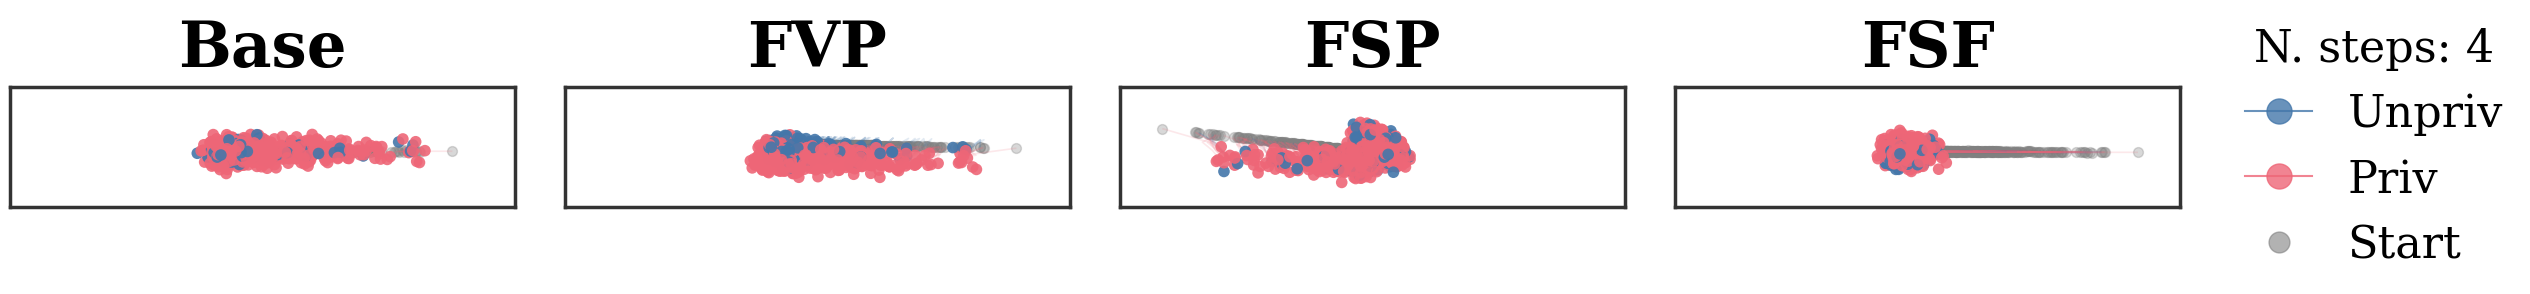

In [ ]:
plt.rcParams.update({
    "text.usetex": False, 
    "font.family": "serif",
    "font.size": 22,
    "axes.grid": False,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18
})

n_steps = 4
s_np = sensitive_col.cpu().numpy().flatten()
graph_size = s_np.shape[0]
dim_L = L.size()[0]

L_indices = L.coalesce().indices()
L_values = L.coalesce().values()
P_indices = P.coalesce().indices()
P_values = P.coalesce().values()

configs = [
    ('Base', L_indices, L_values, None, 1.0),
    ('FVP', L_indices, L_values, s_tensor, 0.5),
    ('FSP', L_indices, L_values, eff_eigenproj, 1.0),
    ('FSF', P_indices, P_values, None, 1.0),
]

results = []
all_coords = []

for name, indices, values, vec, alpha_val in configs:
    x_curr = bund_proj.clone()
    history = [x_curr.detach().cpu().numpy()]
    
    for _ in range(n_steps):
        x_reshaped = x_curr.view(dim_L, -1)
        
        if vec is not None:
            if vec.numel() == x_reshaped.numel():
                 vec_reshaped = vec.view(dim_L, -1)
            elif vec.shape[0] == dim_L:
                 vec_reshaped = vec
            else:
                 vec_reshaped = vec 

            x_diff = diffusion(indices, values, x_reshaped, dim_L, 1, vector=vec_reshaped, alpha=alpha_val)
        else:
            x_diff = diffusion(indices, values, x_reshaped, dim_L, 1)
        
        x_curr = x_diff.view(graph_size, -1)
        history.append(x_curr.detach().cpu().numpy())
    
    full_history = np.vstack(history)
    pca = PCA(n_components=2)
    full_coords_2d = pca.fit_transform(full_history)
    coords = full_coords_2d.reshape(n_steps + 1, graph_size, 2)
        
    results.append((name, coords))
    all_coords.append(coords)

all_coords_concat = np.concatenate(all_coords, axis=0).reshape(-1, 2)
x_min, x_max = all_coords_concat[:, 0].min(), all_coords_concat[:, 0].max()
y_min, y_max = all_coords_concat[:, 1].min(), all_coords_concat[:, 1].max()
margin = 0.1 * max(x_max - x_min, y_max - y_min)

fig, axes = plt.subplots(1, 4, figsize=(28, 7))

shuffle_idx = np.arange(graph_size)
np.random.shuffle(shuffle_idx)

node_colors_base = np.where(s_np < 0, col_unprivileged, col_privileged)

for i, (ax, (name, coords)) in enumerate(zip(axes, results)):
    
    segments = []
    for k in range(graph_size):
        segments.append(coords[:, k, :])
    segments = np.array(segments)
    
    segments_shuffled = segments[shuffle_idx]
    colors_shuffled = node_colors_base[shuffle_idx]
    
    lc = LineCollection(segments_shuffled, colors=colors_shuffled, alpha=0.15, linewidth=1.2, zorder=2)
    ax.add_collection(lc)
    
    start_x, start_y = coords[0, :, 0], coords[0, :, 1]
    
    end_x = coords[-1, :, 0]
    end_y = coords[-1, :, 1]
    
    jitter_strength = 0.015 * (x_max - x_min)
    end_x_jitter = end_x + np.random.normal(0, jitter_strength, size=end_x.shape)
    end_y_jitter = end_y + np.random.normal(0, jitter_strength, size=end_y.shape)
    
    end_x_shuffled = end_x_jitter[shuffle_idx]
    end_y_shuffled = end_y_jitter[shuffle_idx]
    
    ax.scatter(start_x, start_y, c='gray', s=50, alpha=0.3, zorder=1)
    
    ax.scatter(end_x_shuffled, end_y_shuffled, c=colors_shuffled, alpha=0.9, s=70, zorder=3, edgecolors='none')

    ax.set_title(name, fontsize=45, fontweight='bold', pad=15)
    ax.set_xticks([])
    ax.set_yticks([])
    
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color('#333333')
        spine.set_linewidth(2.5)

    ax.set_xlim(x_min - margin, x_max + margin)
    ax.set_ylim(y_min - margin, y_max + margin)
    ax.set_aspect('equal', adjustable='box')

    if i == 3:
        proxy_lines = [
            mlines.Line2D([], [], color=col_unprivileged, marker='o', linestyle='-', markersize=18, label='Unpriv', alpha=0.8),
            mlines.Line2D([], [], color=col_privileged, marker='o', linestyle='-', markersize=18, label='Priv', alpha=0.8),
            mlines.Line2D([], [], color='gray', marker='o', linestyle='None', markersize=15, label='Start', alpha=0.6)
        ]
        ax.legend(handles=proxy_lines, 
                  loc='center left', 
                  bbox_to_anchor=(1.05, 0.5),
                  frameon=False, 
                  fontsize=32,
                  title=f"N. steps: {n_steps}",
                  title_fontsize=32,
                  handlelength=1.5)

plt.subplots_adjust(wspace=0.1)
plt.savefig(path / "dynamic_pca.pdf", bbox_inches='tight')
plt.show()